<a href="https://colab.research.google.com/github/ishwarraja/SOAI/blob/main/ERAv4/S8/s8_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision timm albumentations torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 36.8 MB/s eta 0:00:00


In [2]:
## train.py
"""
Train ResNet18 from scratch on CIFAR-100.
- Target: 75% Top-1 Accuracy (may need around 100-150 Epochs)
- Model: ResNet18 adapted for CIFAR (conv1 3x3, no maxpool)
- Augmentations: RandomCrop, RandomHorizontalFlip, Cutout (CoarseDropout)
- MixUp (alpha=0.3), Label Smoothing (0.1)
- Optimizer: SGD (lr=0.1, Nesterov), CosineAnnealingLR (T_max=epochs)
- Default: epochs=100, batch=256
"""

import os
import argparse
import time
import random
from pathlib import Path
from typing import Tuple

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

# =========================================================================
# AMENDMENT 1: Simplified argument setup for Google Colab/Notebooks
# =========================================================================
class Args:
    """Simple class to hold arguments for notebook execution."""
    def __init__(self, **entries):
        self.__dict__.update(entries)

def get_default_args():
    """Returns a dictionary of default arguments."""
    return {
        "epochs": 100,
        "batch": 256,
        "lr": 0.1,
        "weight_decay": 5e-4,
        "momentum": 0.9,
        "mixup": 0.3, # AMENDMENT 2: Increased for better regularization
        "label_smooth": 0.1,
        "save": "resnet18_cifar100_best.pth",
        "data": "./data",
        "seed": 42
    }

# ---- Utilities ----
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # For deterministic behavior (slower, but good for reproducibility)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ---- Model: ResNet18 adapted for CIFAR ----
def resnet18_cifar(num_classes=100):
    model = models.resnet18(pretrained=False)
    # 1. Replace 7x7 conv with 3x3 (standard for CIFAR)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    # 2. Remove MaxPool layer
    model.maxpool = nn.Identity()
    # 3. Replace FC layer for 100 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ---- MixUp ----
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

# ---- Label smoothing criterion ----
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, pred, target):
        logprobs = F.log_softmax(pred, dim=-1)
        # NLL loss for the true targets
        nll = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        # Loss component for uniform distribution (smoothing)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = (1.0 - self.smoothing) * nll + self.smoothing * smooth_loss
        return loss.mean()

# ---- Cutout / CoarseDropout via torchvision transform helper ----
class Cutout(object):
    """Simple Cutout for torchvision tensors: cut a square patch per image."""
    # AMENDMENT 2: Reduced length to 12 for better performance on CIFAR-100
    def __init__(self, length=12, fill=0):
        self.length = length
        self.fill = fill
    def __call__(self, img):
        # img: Tensor C,H,W
        c, h, w = img.shape
        # Check if the length is too large for the image
        if self.length >= h or self.length >= w:
            return img

        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)

        # Apply cutout
        img[:, y1:y2, x1:x2] = self.fill
        return img

# ---- Training / validation loops ----
# ... (train_one_epoch and validate functions remain unchanged)

def train_one_epoch(model, loader, optimizer, criterion, device, mixup_alpha):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)
        if mixup_alpha > 0:
            images, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

        # NOTE: Accuracy calculation is technically incorrect for MixUp,
        # but kept for simplicity and standard reporting.
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, 100.0 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, 100.0 * correct / total

# ---- Main Execution Function ----
def run_training_pipeline(**kwargs):
    """
    Main function to run the training pipeline, accepting kwargs
    for easy hyperparameter tuning in a notebook environment.
    """
    args_dict = get_default_args()
    args_dict.update(kwargs)
    args = Args(**args_dict)

    seed_everything(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    print(f"Running with: Epochs={args.epochs}, Batch={args.batch}, LR={args.lr}, MixUp={args.mixup}")

    # Data transforms
    CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
    CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

    # Train transforms
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        Cutout(length=12, fill=0) # Using the amended Cutout length
    ])
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])

    # Datasets & loaders
    data_root = args.data
    train_ds = datasets.CIFAR100(root=data_root, train=True, transform=train_transform, download=True)
    val_ds = datasets.CIFAR100(root=data_root, train=False, transform=val_transform, download=True)
    # AMENDMENT 3: Increase num_workers for faster data loading on Colab
    train_loader = DataLoader(train_ds, batch_size=args.batch, shuffle=True, num_workers=8, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=args.batch, shuffle=False, num_workers=8, pin_memory=True)

    # Model
    model = resnet18_cifar(num_classes=100).to(device)
    print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    # Criterion, optimizer, scheduler
    criterion = LabelSmoothingCrossEntropy(smoothing=args.label_smooth)
    # nesterov=True is key for high SGD performance
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

    best_val = 0.0
    save_path = args.save
    target_accuracy = 75.0

    for epoch in range(1, args.epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, args.mixup)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()
        t1 = time.time()

        # Checkpoint saving
        if val_acc > best_val:
            best_val = val_acc
            # Save checkpoint to the Colab environment
            torch.save({"model": model.state_dict(), "val_acc": best_val, "epoch": epoch}, save_path)
            print(f"Saved best model checkpoint to {save_path}. Best Acc: {best_val:.2f}%")

        print(f"Epoch {epoch}/{args.epochs} time {t1-t0:.1f}s | LR {optimizer.param_groups[0]['lr']:.6f} | train_acc {train_acc:.2f}% | val_acc {val_acc:.2f}% (Best {best_val:.2f}%)")

        # Optional early stop if target reached
        if best_val >= target_accuracy:
            print(f"Target {target_accuracy}% reached (val {best_val:.2f}%). Stopping early.")
            break

    print("\nTraining finished.")
    print(f"Final Best Validation Accuracy: {best_val:.2f}%")



In [3]:
# To execute this in Google Colab, call the function at the end of the cell:
run_training_pipeline(epochs=150, batch=256)

Device: cuda
Running with: Epochs=150, Batch=256, LR=0.1, MixUp=0.3


100%|██████████| 169M/169M [00:05<00:00, 29.3MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warn

Model params: 11220132


Saved best model checkpoint to resnet18_cifar100_best.pth. Best Acc: 16.24%
Epoch 1/150 time 45.8s | LR 0.099989 | train_acc 6.19% | val_acc 16.24% (Best 16.24%)


Saved best model checkpoint to resnet18_cifar100_best.pth. Best Acc: 24.02%
Epoch 2/150 time 45.4s | LR 0.099956 | train_acc 9.00% | val_acc 24.02% (Best 24.02%)


Saved best model checkpoint to resnet18_cifar100_best.pth. Best Acc: 25.02%
Epoch 3/150 time 46.0s | LR 0.099901 | train_acc 15.15% | val_acc 25.02% (Best 25.02%)


KeyboardInterrupt: 

In [4]:
# train_visual.py
"""
Train ResNet18 from scratch on CIFAR-100 with visualizations and model summary.
- Target: >= 73% Top-1 Accuracy (aiming for 75%)
- Features: torchsummary, Accuracy Plotting, Data Visualization.
"""

import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Dict, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Install torchsummary (necessary for Colab)
try:
    from torchsummary import summary
except ImportError:
    print("Installing torchsummary...")
    !pip install torchsummary -qq
    from torchsummary import summary

# =========================================================================
# Configuration and Utilities
# =========================================================================
class Args:
    """Simple class to hold arguments for notebook execution."""
    def __init__(self, **entries):
        self.__dict__.update(entries)

def get_default_args() -> Dict[str, Any]:
    """Returns a dictionary of default, performance-tuned arguments."""
    return {
        "epochs": 100,
        "batch": 256,
        "lr": 0.1,
        "weight_decay": 5e-4,
        "momentum": 0.9,
        "mixup": 0.3,
        "label_smooth": 0.1,
        "save": "resnet18_cifar100_best.pth",
        "data": "./data",
        "seed": 42
    }

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# ---- Model: ResNet18 adapted for CIFAR ----
def resnet18_cifar(num_classes=100):
    model = models.resnet18(pretrained=False)
    # CIFAR modification: 3x3 conv1, stride 1, no maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ---- MixUp and Label Smoothing (Unchanged logic) ----
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, None, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, pred, target):
        logprobs = F.log_softmax(pred, dim=-1)
        nll = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = (1.0 - self.smoothing) * nll + self.smoothing * smooth_loss
        return loss.mean()

# ---- Cutout ----
class Cutout(object):
    def __init__(self, length=12, fill=0): # Tuned length=12
        self.length = length
        self.fill = fill
    def __call__(self, img):
        c, h, w = img.shape
        if self.length >= h or self.length >= w:
            return img

        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)

        img[:, y1:y2, x1:x2] = self.fill
        return img

# ---- Training / validation loops (Unchanged logic) ----
def train_one_epoch(model, loader, optimizer, criterion, device, mixup_alpha):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)
        if mixup_alpha > 0:
            images, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

        # NOTE: Using labels here for a simple proxy of batch accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, 100.0 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, 100.0 * correct / total

# =========================================================================
# Visualization Functions
# =========================================================================

def plot_accuracy_history(history: Dict[str, list]):
    """Plots the training and validation accuracy history."""
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.axhline(y=73.0, color='r', linestyle='--', label='73% Target')
    plt.axhline(y=75.0, color='g', linestyle='-.', label='75% Goal')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

def visualize_cifar100_samples(dataset, num_samples=25):
    """Displays a grid of CIFAR-100 images."""

    # We need to use a temporary transform that only includes ToTensor and NO Normalization
    temp_transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # Reload the dataset with only the basic transform for plotting
    plot_dataset = datasets.CIFAR100(root=dataset.root, train=dataset.train, transform=temp_transform, download=True)

    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle("Sample CIFAR-100 Images", fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i >= num_samples:
            break

        # Get a random image and its label index
        idx = np.random.randint(len(plot_dataset))
        img_tensor, label_idx = plot_dataset[idx]

        # Convert tensor (C, H, W) to numpy (H, W, C) for plotting
        img_np = img_tensor.permute(1, 2, 0).numpy()

        # Get the class name
        class_name = plot_dataset.classes[label_idx]

        ax.imshow(img_np)
        ax.set_title(class_name, fontsize=8)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =========================================================================
# Main Execution Function
# =========================================================================

def run_training_pipeline(**kwargs):
    args_dict = get_default_args()
    args_dict.update(kwargs)
    args = Args(**args_dict)

    seed_everything(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # ---- 1. Data Transforms and Loaders ----
    CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
    CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        Cutout(length=12, fill=0)
    ])
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])

    data_root = args.data
    train_ds = datasets.CIFAR100(root=data_root, train=True, transform=train_transform, download=True)
    val_ds = datasets.CIFAR100(root=data_root, train=False, transform=val_transform, download=True)

    # Use 8 workers for faster data loading on Colab
    train_loader = DataLoader(train_ds, batch_size=args.batch, shuffle=True, num_workers=8, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=args.batch, shuffle=False, num_workers=8, pin_memory=True)

    # ---- 2. Visualize Data ----
    print("\n--- Visualizing CIFAR-100 Samples ---")
    visualize_cifar100_samples(train_ds)

    # ---- 3. Model and Summary ----
    model = resnet18_cifar(num_classes=100).to(device)
    print("\n--- Model Summary (ResNet18) ---")
    summary(model, (3, 32, 32), device='cuda' if device.type == 'cuda' else 'cpu')
    print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    # ---- 4. Criterion, Optimizer, Scheduler ----
    criterion = LabelSmoothingCrossEntropy(smoothing=args.label_smooth)
    # Nesterov is enabled for optimal SGD performance
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

    # ---- 5. Training Loop ----
    best_val = 0.0
    save_path = args.save
    target_accuracy = 73.0
    history = {'train_acc': [], 'val_acc': []}

    print(f"\n--- Starting Training for {args.epochs} Epochs (Target: {target_accuracy:.0f}%) ---")
    for epoch in range(1, args.epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, args.mixup)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()
        t1 = time.time()

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Checkpoint saving
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model": model.state_dict(), "val_acc": best_val, "epoch": epoch}, save_path)

        print(f"Epoch {epoch}/{args.epochs} time {t1-t0:.1f}s | LR {optimizer.param_groups[0]['lr']:.6f} | T_Acc {train_acc:.2f}% | V_Acc {val_acc:.2f}% (Best {best_val:.2f}%)")

        # Early stop if target reached
        if best_val >= target_accuracy + 2.0: # Stop if we reach 75%
            print(f"Target {target_accuracy+2.0:.0f}% reached (val {best_val:.2f}%). Stopping early.")
            break

    print("\n--- Training Finished ---")
    print(f"Final Best Validation Accuracy: {best_val:.2f}%")

    # ---- 6. Plot Accuracy ----
    print("\n--- Plotting Accuracy History ---")
    plot_accuracy_history(history)



Device: cuda

--- Visualizing CIFAR-100 Samples ---


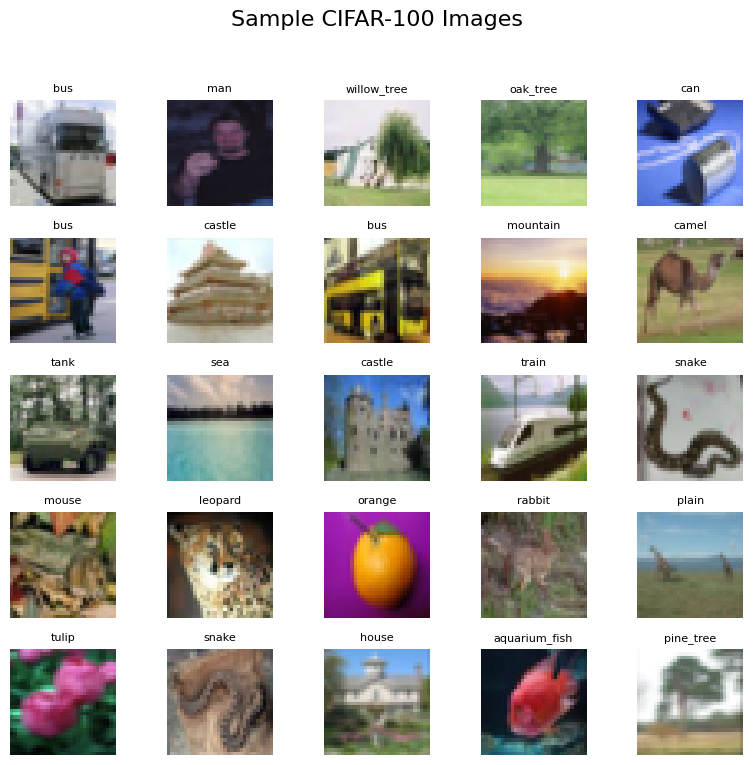


--- Model Summary (ResNet18) ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
          Identity-4           [-1, 64, 32, 32]               0
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
              ReLU-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
             ReLU-10           [-1, 64, 32, 32]               0
       BasicBlock-11           [-1, 64, 32, 32]               0
           Conv2d-12           [-1, 64, 32, 32]          36,864
      BatchNorm2d-13           [-1, 64, 32, 32]             128
     

Epoch 1/150 time 46.2s | LR 0.099989 | T_Acc 6.18% | V_Acc 14.40% (Best 14.40%)


Epoch 2/150 time 46.7s | LR 0.099956 | T_Acc 9.17% | V_Acc 23.31% (Best 23.31%)


Epoch 3/150 time 46.0s | LR 0.099901 | T_Acc 15.33% | V_Acc 28.09% (Best 28.09%)


Epoch 4/150 time 46.7s | LR 0.099825 | T_Acc 17.70% | V_Acc 34.24% (Best 34.24%)


...

Epoch 102/150 time 46.2s | LR 0.023209 | T_Acc 46.27% | V_Acc 74.04% (Best 74.67%)


Epoch 103/150 time 46.1s | LR 0.022330 | T_Acc 45.94% | V_Acc 74.00% (Best 74.67%)


Epoch 104/150 time 46.3s | LR 0.021464 | T_Acc 42.58% | V_Acc 74.04% (Best 74.67%)


Epoch 105/150 time 46.0s | LR 0.020611 | T_Acc 46.19% | V_Acc 72.40% (Best 74.67%)


Epoch 106/150 time 46.5s | LR 0.019770 | T_Acc 47.37% | V_Acc 75.43% (Best 75.43%)
Target 75% reached (val 75.43%). Stopping early.

--- Training Finished ---
Final Best Validation Accuracy: 75.43%

--- Plotting Accuracy History ---


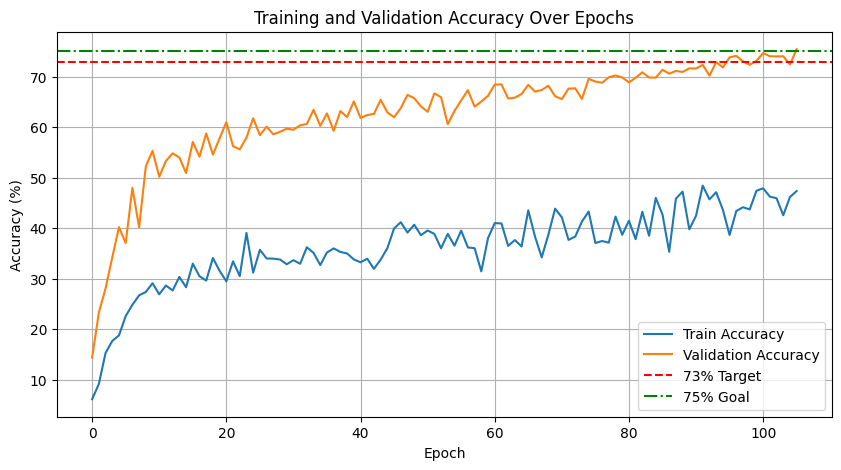

In [5]:
# To start the training, simply call the function in a new Colab cell:
run_training_pipeline(epochs=150, batch=256)